# Phân tích dữ liệu POI — Where2Go DSS

Notebook phục vụ báo cáo đề tài **POI Recommendation System**. Chạy **Restart Kernel → Run All**
hoặc `python scripts/run_analysis.py`. Chỉ đọc dataset, không crawl, không publish catalog, không cần OSRM.
Các biểu đồ PNG và bảng tổng hợp được xuất vào `docs/assets/poi/` và `data/reports/analysis/`.

**Câu hỏi nghiên cứu:** dữ liệu đến từ đâu, tập trung ở đâu, thiếu trường nào, có đủ để xếp hạng và lập lịch không?
Mọi tỷ lệ bên dưới ghi rõ mẫu số. `tool_confirmed` không đồng nghĩa khảo sát thực địa;
rating cộng đồng không phải nhãn phù hợp cá nhân. Kết quả evaluator có sẵn được đọc như một nghiên cứu tình huống,
không phải tập test hành vi người dùng. Notebook không huấn luyện LORE hoặc mô hình graph của bài 2020.

In [1]:
from pathlib import Path
from datetime import date
import hashlib
import json
import sys
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "where2go/v2/ranking.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA = ROOT / "data/reports/v2/dataset"
OUT = ROOT / "data/reports/analysis"
FIG = ROOT / "docs/assets/poi"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
REFERENCE_DATE = date(2026, 9, 18)  # Cố định để tái lập; đổi khi lập báo cáo cho snapshot mới.
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 115, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12, "font.size": 10})
COLOR = "#167d9a"

def read(name):
    return pd.read_csv(DATA / name, keep_default_na=True)

def truth(series):
    return series.fillna(False).astype(str).str.lower().isin(["true", "1", "1.0"])

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / (name + ".png"), dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

def table(frame, name):
    frame.to_csv(OUT / (name + ".csv"), index=False, encoding="utf-8-sig")
    display(frame)

summary = json.loads((DATA / "summary.json").read_text(encoding="utf-8"))
pois, ratings, hours = read("pois.csv"), read("ratings.csv"), read("opening_hours.csv")
durations, access = read("duration_profiles.csv"), read("access_points.csv")
sources, provenance, images = read("sources.csv"), read("field_provenance.csv"), read("images.csv")
N = len(pois)
assert N == summary["poi_count"] and pois.poi_id.is_unique
assert set(pois.dataset_version) == {summary["dataset_version"]}
for child in (ratings, hours, durations, access, provenance, images):
    assert set(child.poi_id.dropna()) <= set(pois.poi_id), "Khóa ngoại không tồn tại"
for name, expected in summary["export_counts"].items():
    assert len(read(name)) == expected, f"Số dòng {name} khác summary"
assert pois.latitude.between(-90, 90).all() and pois.longitude.between(-180, 180).all()
display(Markdown(f"**Snapshot:** `{summary['dataset_version']}` — **{N:,} POI**, ngày phân tích cố định {REFERENCE_DATE}."))
display(pd.DataFrame({"bảng": ["POI", "rating", "giờ", "thời lượng", "tiếp cận", "nguồn", "ảnh", "nguồn từng trường"],
                      "số dòng": [len(x) for x in (pois, ratings, hours, durations, access, sources, images, provenance)]}))

**Snapshot:** `v2-ae66988a1053d0de` — **16,018 POI**, ngày phân tích cố định 2026-09-18.

,bảng,số dòng
0,POI,16018
1,rating,1277
2,giờ,9136
3,thời lượng,16018
4,tiếp cận,16125
5,nguồn,11
6,ảnh,1512
7,nguồn từng trường,162659


## 1. Nguồn và đơn vị quan sát

Một POI có thể có nhiều nguồn, nhiều rating, nhiều khoảng giờ và nhiều ảnh. Vì vậy số dòng các bảng con
không phải số POI. Ba workbook là các phiên bản chồng lặp; không cộng 25.621 dòng thành 25.621 thực thể.
Tên HOTOSM trong workbook không chứng minh mỗi trường của dòng đều do HOTOSM cung cấp.

,file,rows,confirmed,unmatched,ambiguous,selected_fields_recovered
0,vietnam_destinations_google_maps_browser_hotos...,8201,1608,6575,18,8149.0
1,vietnam_destinations_google_maps_browser_hotos...,8710,1623,7069,18,4.0
2,vietnam_destinations_google_maps_browser_hotos...,8710,1622,7070,18,0.0


**25,621 dòng nguồn**, hợp **8,710 STT**, **1,569 POI liên kết**. 4,853 dòng liên kết không phải các POI độc lập.

,source,selected_field_count
0,data/catalog.sqlite,100771
1,data/raw/vietnam-260915.osm.pbf,49517
2,data/vietnam_destinations_google_maps_browser_...,11894
3,data/enrichment/accepted-expansion.json,324
4,data/enrichment/accepted-pilot.json,109
5,data/manual/poi_enrichment_v2.xlsx,25
6,data/curation/poi_relations_v2.csv,11
7,data/curation/focus_landmarks_v2.csv,4
8,data/vietnam_destinations_google_maps_browser_...,4


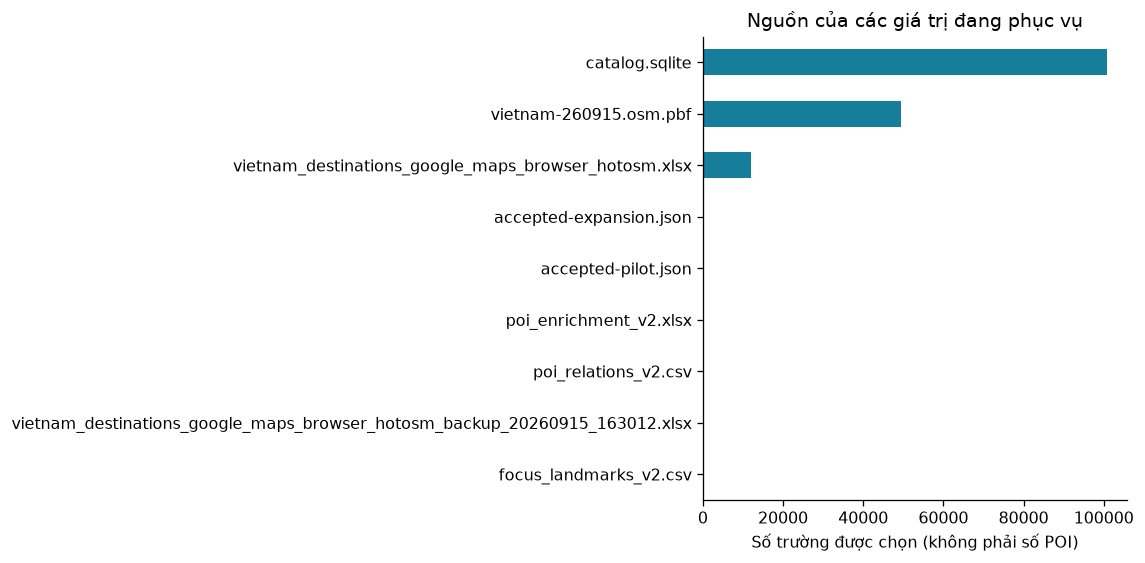

In [2]:
merge = summary["merge_stats"]
workbooks = pd.DataFrame([dict(file=k, **v) for k, v in merge["sources"].items()]).fillna(0)
table(workbooks[["file", "rows", "confirmed", "unmatched", "ambiguous", "selected_fields_recovered"]], "workbook_merge")
display(Markdown(f"**{merge['rows']:,} dòng nguồn**, hợp **{merge['unique_legacy_ids']:,} STT**, "
                 f"**{merge['linked_unique_pois']:,} POI liên kết**. {merge['confirmed']:,} dòng liên kết không phải các POI độc lập."))
source_fields = provenance.groupby("logical_path", dropna=False).size().sort_values(ascending=False)
source_table = source_fields.rename_axis("source").reset_index(name="selected_field_count")
table(source_table, "selected_fields_by_source")
plot_sources = source_fields.copy()
plot_sources.index = [Path(str(x)).name for x in plot_sources.index]
plot_sources.head(10).sort_values().plot.barh(figsize=(10, 5), color=COLOR)
plt.xlabel("Số trường được chọn (không phải số POI)")
plt.title("Nguồn của các giá trị đang phục vụ")
savefig("01_nguon_du_lieu")

## 2. Phân bổ theo địa phương, loại hình và không gian

Mẫu số là toàn catalog. Hà Nội/Đà Nẵng được bổ sung nhà hàng và quán cà phê có chủ đích,
nên biểu đồ phản ánh thiết kế thu thập và mức đóng góp nguồn, không đo mật độ địa điểm du lịch thực của Việt Nam.
Đà Nẵng dùng địa giới trong snapshot, gồm khu vực Quảng Nam cũ.

,location,count,percent
0,Hà Nội,4499,28.087152
1,Đà Nẵng,2752,17.180672
2,Hồ Chí Minh,2419,15.101761
3,An Giang,637,3.976776
4,Đồng Nai,552,3.446123
5,Tây Ninh,424,2.647022
6,Lâm Đồng,421,2.628293
7,Bắc Ninh,380,2.372331
8,Huế,361,2.253715
9,Cần Thơ,326,2.035210


,category,count,percent
0,temple,6068,37.882382
1,restaurant,2909,18.160819
2,cafe,2335,14.577350
3,park,1500,9.364465
4,attraction,969,6.049444
5,historic,902,5.631165
6,market,422,2.634536
7,museum,338,2.110126
8,viewpoint,260,1.623174
9,beach,126,0.786615


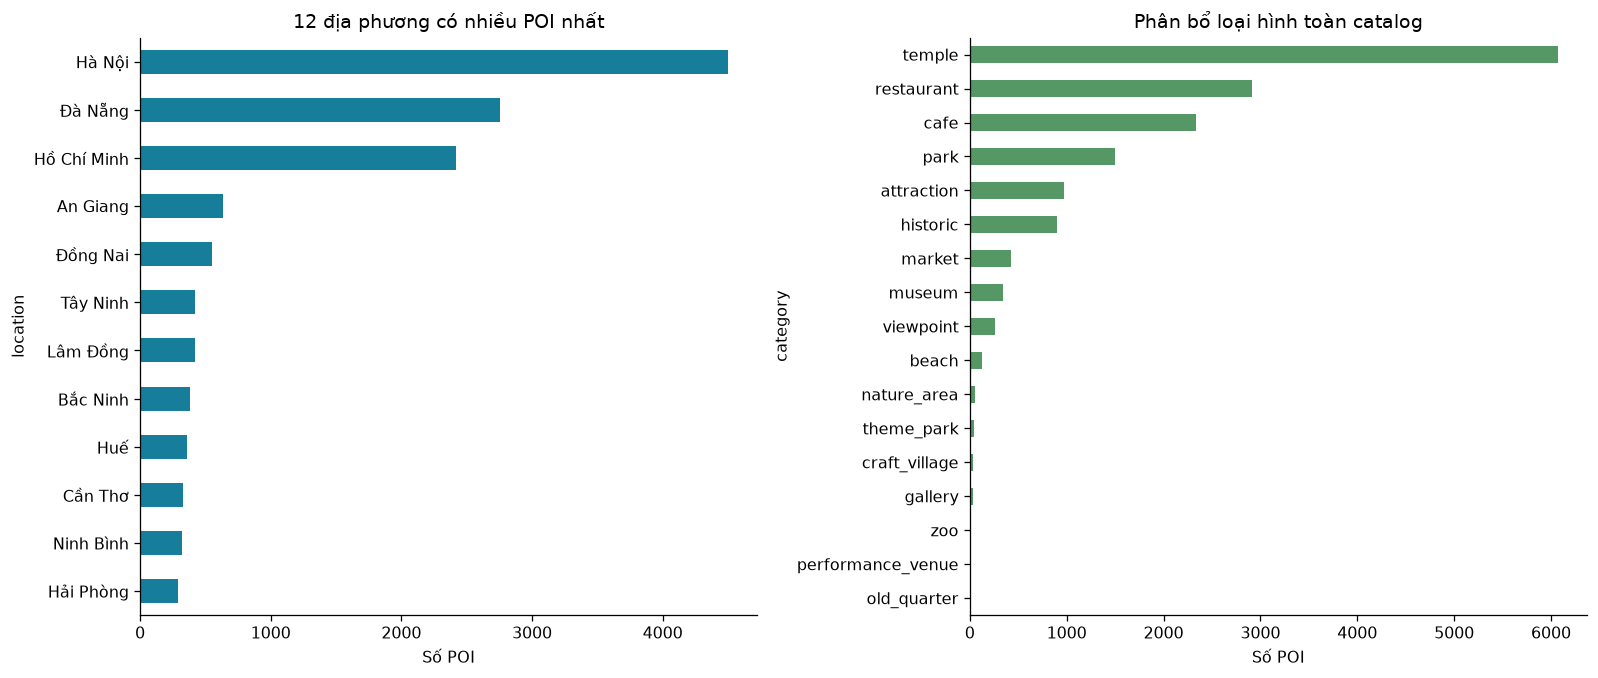

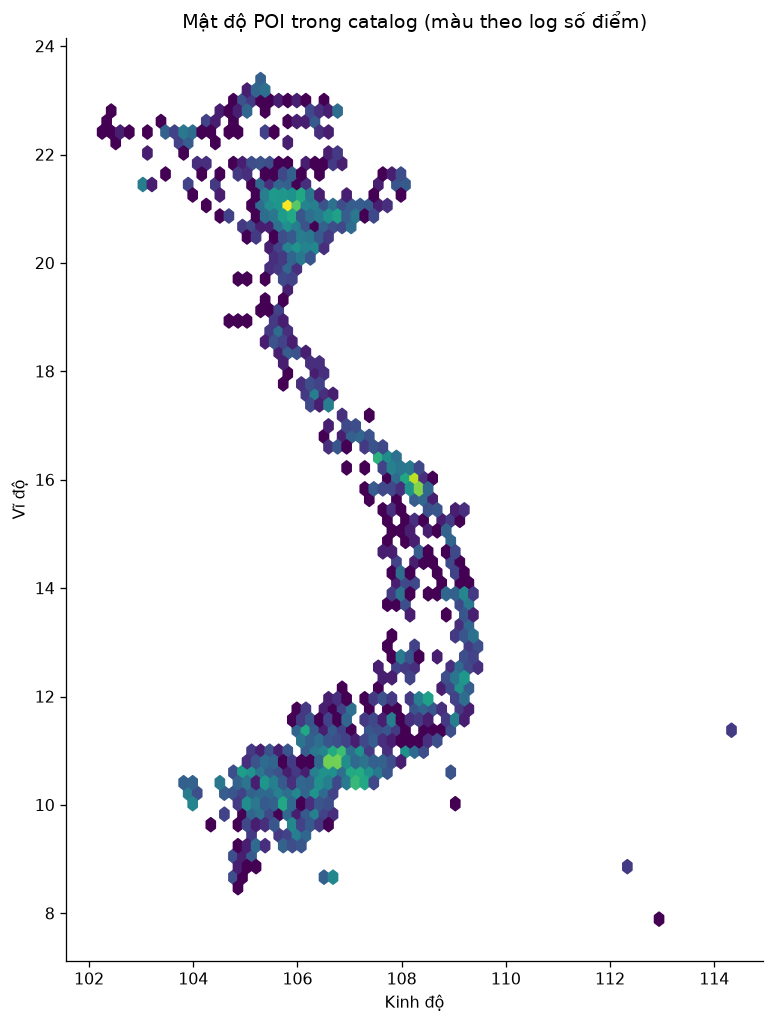

Hai địa phương nhiều dữ liệu nhất chiếm **45.27%** catalog. Biểu đồ tọa độ không phải kiểm định từng điểm nằm đúng địa giới hoặc đúng cổng vào.

In [3]:
locations = pois.groupby("location", dropna=False).size().sort_values(ascending=False)
categories = pois.groupby("category").size().sort_values(ascending=False)
table(locations.rename_axis("location").reset_index(name="count").assign(percent=lambda d: 100*d["count"]/N), "location_distribution")
table(categories.rename_axis("category").reset_index(name="count").assign(percent=lambda d: 100*d["count"]/N), "category_distribution")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
locations.head(12).sort_values().plot.barh(ax=axes[0], color=COLOR)
categories.sort_values().plot.barh(ax=axes[1], color="#559866")
axes[0].set_title("12 địa phương có nhiều POI nhất")
axes[1].set_title("Phân bổ loại hình toàn catalog")
for ax in axes:
    ax.set_xlabel("Số POI")
savefig("02_phan_bo")
fig, ax = plt.subplots(figsize=(7, 9))
ax.hexbin(pois.longitude, pois.latitude, gridsize=70, mincnt=1, bins="log", cmap="viridis")
ax.set(xlabel="Kinh độ", ylabel="Vĩ độ", title="Mật độ POI trong catalog (màu theo log số điểm)")
ax.set_aspect(1 / np.cos(np.deg2rad(16)))
savefig("03_khong_gian")
top_share = float(locations.head(2).sum()/N)
display(Markdown(f"Hai địa phương nhiều dữ liệu nhất chiếm **{100*top_share:.2f}%** catalog. "
                 "Biểu đồ tọa độ không phải kiểm định từng điểm nằm đúng địa giới hoặc đúng cổng vào."))

## 3. Độ đầy đủ và điều kiện phục vụ

Phân biệt: có trong catalog → khám phá được → có metadata đủ điều kiện gợi ý tự động.
Người dùng vẫn có thể tự chọn điểm thiếu rating/giờ nếu danh tính, vị trí và trạng thái phù hợp.
`has_structured_hours` có thể chỉ biết một phần tuần; khác `has_full_week_hours`.

,field,present,denominator,percent
0,Tên,16018,16018,100.000000
1,Tọa độ,16018,16018,100.000000
2,Mô tả,1693,16018,10.569359
3,Website,554,16018,3.458609
4,Ảnh đã chọn,1048,16018,6.542640
5,Rating hợp lệ,86,16018,0.536896
6,Giờ có cấu trúc,1244,16018,7.766263
7,Giờ đủ 7 ngày,1174,16018,7.329255
8,Thời lượng riêng,33,16018,0.206018
9,Thời lượng xác minh,0,16018,0.000000


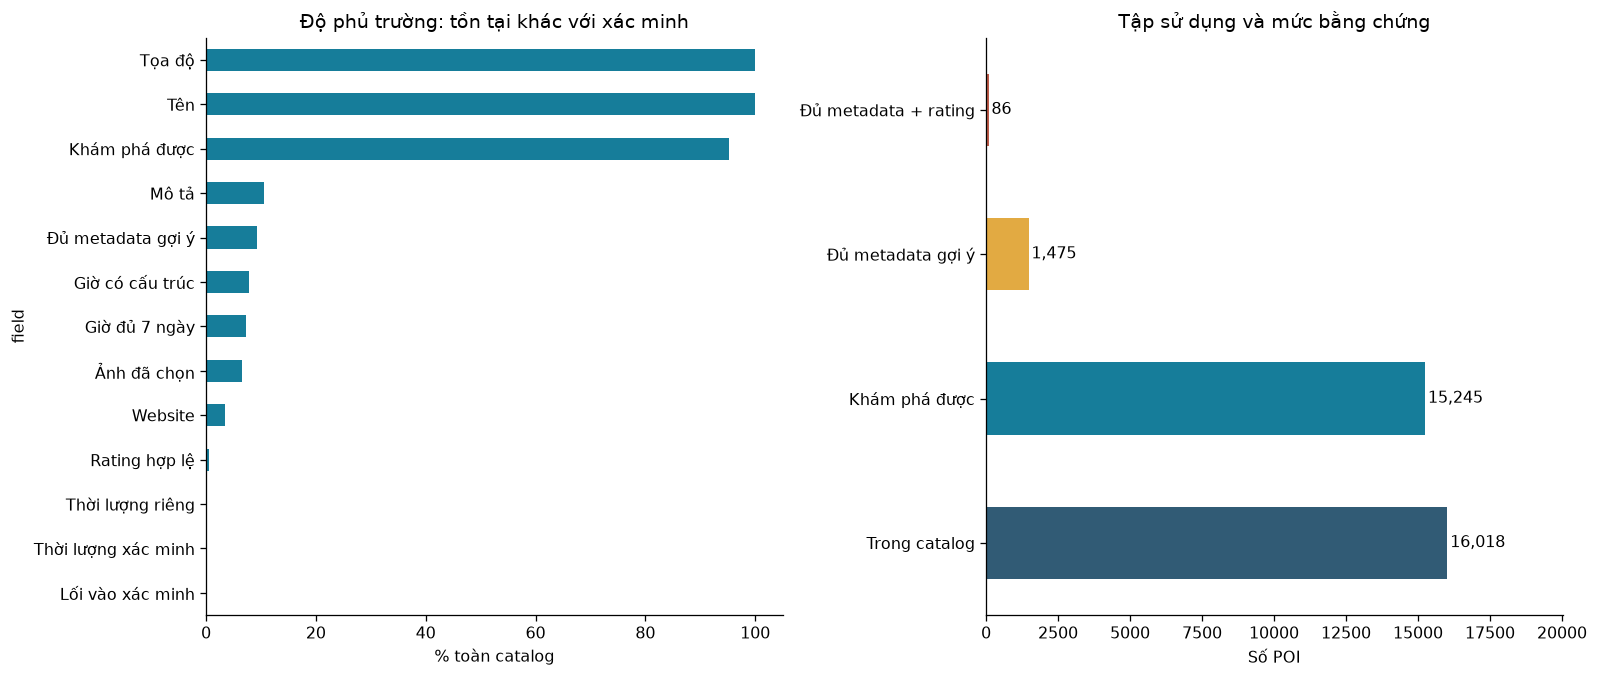

,location,scope,denominator,Tên,Tọa độ,Mô tả,Website,Ảnh đã chọn,Rating hợp lệ,Giờ có cấu trúc,Giờ đủ 7 ngày,Thời lượng riêng,Thời lượng xác minh,Lối vào xác minh,Khám phá được,Đủ metadata gợi ý
0,Hà Nội,tất cả,4499,100.0,100.0,5.96,6.25,3.16,0.87,13.85,13.20,0.33,0.0,0.0,98.11,16.49
1,Hà Nội,usable,4485,100.0,100.0,5.98,6.27,3.17,0.87,13.89,13.24,0.33,0.0,0.0,98.42,16.54
2,Hà Nội,đủ metadata,742,100.0,100.0,4.99,37.47,5.39,5.26,82.88,79.11,2.02,0.0,0.0,100.00,100.00
3,Đà Nẵng,tất cả,2752,100.0,100.0,3.49,6.61,2.91,1.71,15.59,14.83,0.65,0.0,0.0,95.68,17.91
4,Đà Nẵng,usable,2691,100.0,100.0,3.57,6.76,2.97,1.75,15.90,15.12,0.67,0.0,0.0,97.84,18.32
5,Đà Nẵng,đủ metadata,493,100.0,100.0,8.72,36.31,10.34,9.53,85.40,81.14,3.65,0.0,0.0,100.00,100.00


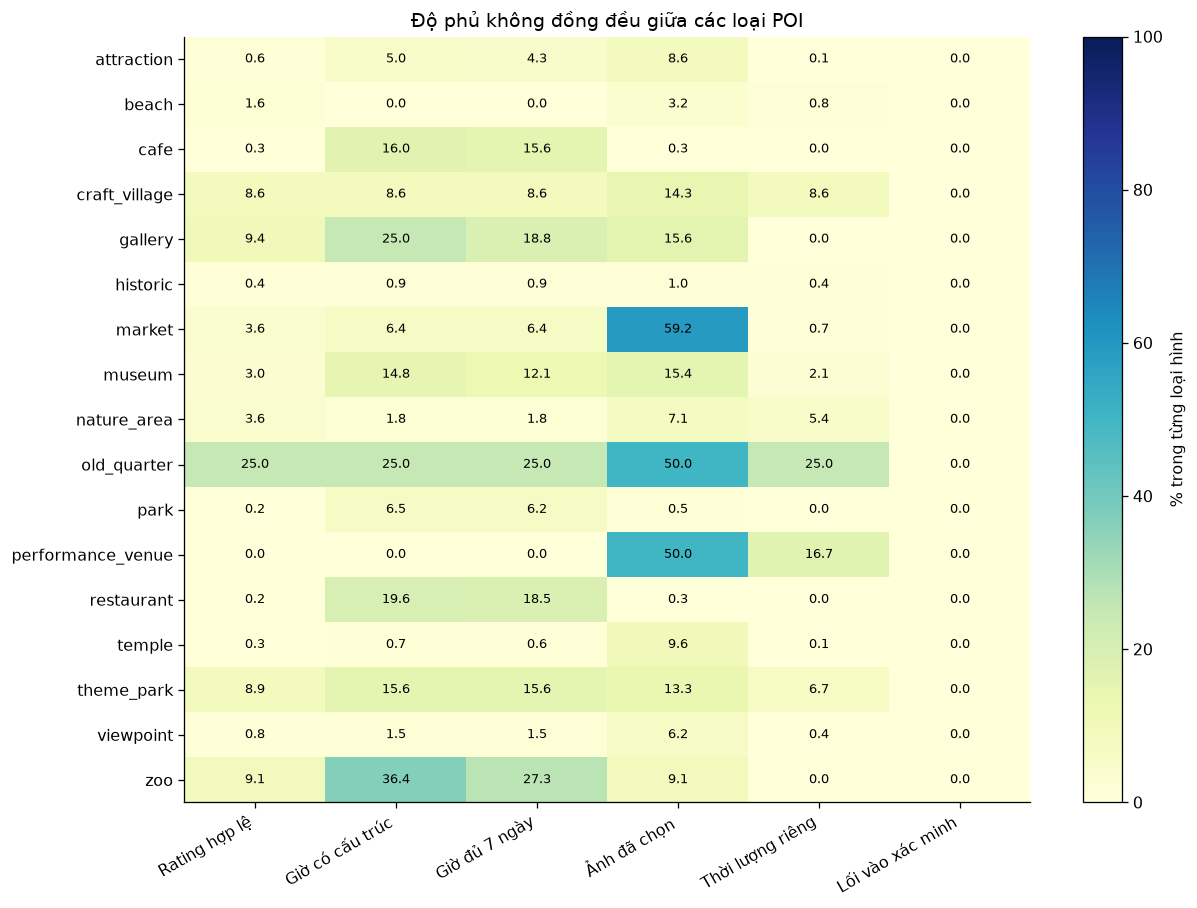

In [4]:
flags = pd.DataFrame({
    "Tên": pois.name.notna(), "Tọa độ": pois.latitude.notna() & pois.longitude.notna(),
    "Mô tả": pois.description.fillna("").str.strip().ne(""), "Website": pois.website.fillna("").str.match(r"https?://"),
    "Ảnh đã chọn": pois.image.notna(), "Rating hợp lệ": pois.rating.notna() & pois.review_count.notna(),
    "Giờ có cấu trúc": truth(pois.has_structured_hours), "Giờ đủ 7 ngày": truth(pois.has_full_week_hours),
    "Thời lượng riêng": pois.duration_method.notna() & pois.duration_method.ne("category_default"),
    "Thời lượng xác minh": pois.duration_verified_at.notna(), "Lối vào xác minh": truth(pois.access_verified),
    "Khám phá được": truth(pois.explorable), "Đủ metadata gợi ý": truth(pois.serving_eligible),
})
coverage = pd.DataFrame({"field": flags.columns, "present": flags.sum().values, "denominator": N,
                         "percent": flags.mean().values*100})
table(coverage, "coverage_all")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
coverage.set_index("field").percent.sort_values().plot.barh(ax=axes[0], color=COLOR)
axes[0].set(xlim=(0, 105), xlabel="% toàn catalog", title="Độ phủ trường: tồn tại khác với xác minh")
funnel = pd.Series({"Trong catalog": N, "Khám phá được": flags["Khám phá được"].sum(),
                    "Đủ metadata gợi ý": flags["Đủ metadata gợi ý"].sum(),
                    "Đủ metadata + rating": (flags["Đủ metadata gợi ý"] & flags["Rating hợp lệ"]).sum()})
funnel.plot.barh(ax=axes[1], color=["#315b75", "#167d9a", "#e2aa42", "#bd5a48"])
for i, value in enumerate(funnel):
    axes[1].text(value+100, i, f"{value:,}", va="center")
axes[1].set(xlim=(0, N*1.25), xlabel="Số POI", title="Tập sử dụng và mức bằng chứng")
savefig("04_do_phu")
focus_rows = []
for city in ["Hà Nội", "Đà Nẵng"]:
    for scope, mask in [("tất cả", pois.location.eq(city)),
                        ("usable", pois.location.eq(city) & pois.status.eq("usable")),
                        ("đủ metadata", pois.location.eq(city) & flags["Đủ metadata gợi ý"])]:
        focus_rows.append({"location": city, "scope": scope, "denominator": int(mask.sum()),
                           **{key: round(100*flags.loc[mask, key].mean(), 2) for key in flags.columns}})
focus = pd.DataFrame(focus_rows)
table(focus, "focus_coverage")
heat_cols = ["Rating hợp lệ", "Giờ có cấu trúc", "Giờ đủ 7 ngày", "Ảnh đã chọn", "Thời lượng riêng", "Lối vào xác minh"]
heat = flags[heat_cols].join(pois.category).groupby("category").mean()*100
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(heat, aspect="auto", vmin=0, vmax=100, cmap="YlGnBu")
ax.set_yticks(range(len(heat)), heat.index)
ax.set_xticks(range(len(heat_cols)), heat_cols, rotation=30, ha="right")
for i in range(len(heat)):
    for j in range(len(heat_cols)):
        ax.text(j, i, f"{heat.iloc[i,j]:.1f}", ha="center", va="center", fontsize=8,
                color="white" if heat.iloc[i,j]>60 else "black")
fig.colorbar(im, ax=ax, label="% trong từng loại hình")
ax.set_title("Độ phủ không đồng đều giữa các loại POI")
savefig("05_do_phu_loai_hinh")

## 4. Rating, số review và mức tin cậy

Chỉ dùng cặp rating–review cùng quan sát đã được chấp nhận. Các rating thừa kế không đủ chứng cứ
được lưu ở bảng quan sát nhưng không được coi là nhãn đúng. Một địa điểm nhiều review không nhất thiết
phù hợp hơn với một người cụ thể; phân phối lệch và thiên lệch thu thập làm hạn chế khả năng suy rộng.

{'observation_rows': 1277,
 'accepted_pair_rows': 101,
 'accepted_pair_pois': 86,
 'selected_rated_pois': 86,
 'rated_serviceable_pois': 86,
 'median_review_count': 543.0,
 'median_rating': 4.5}

,rating,review_count
count,86.000000,86.000000
mean,4.481416,6160.255814
std,0.300631,12422.498481
min,3.700000,1.000000
25%,4.300000,77.750000
50%,4.500000,543.000000
75%,4.700000,5428.750000
max,5.000000,71657.000000


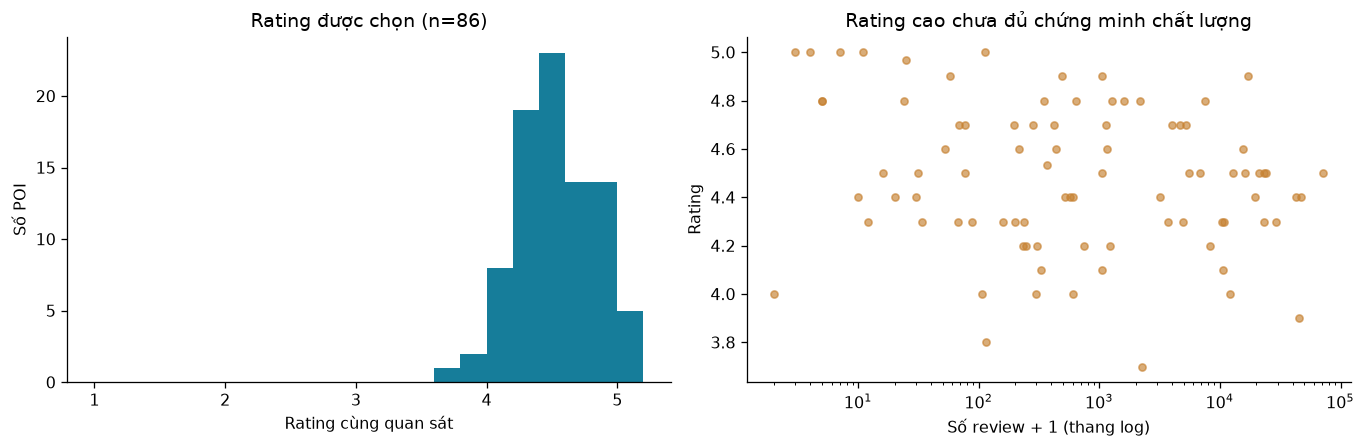

In [5]:
paired = ratings[truth(ratings.same_observation) & ratings.rating.between(1, 5) & ratings.review_count.ge(0)].copy()
rated = pois[flags["Rating hợp lệ"]].copy()
assert rated.rating.between(1, 5).all() and rated.review_count.ge(0).all()
rating_stats = {"observation_rows": len(ratings), "accepted_pair_rows": len(paired),
                "accepted_pair_pois": int(paired.poi_id.nunique()), "selected_rated_pois": len(rated),
                "rated_serviceable_pois": int((flags["Rating hợp lệ"] & flags["Đủ metadata gợi ý"]).sum()),
                "median_review_count": float(rated.review_count.median()), "median_rating": float(rated.rating.median())}
display(rating_stats)
display(rated[["rating", "review_count"]].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rated.rating, bins=np.arange(1, 5.21, .2), color=COLOR)
axes[0].set(xlabel="Rating cùng quan sát", ylabel="Số POI", title=f"Rating được chọn (n={len(rated)})")
axes[1].scatter(rated.review_count + 1, rated.rating, alpha=.65, s=20, color="#c68131")
axes[1].set_xscale("log")
axes[1].set(xlabel="Số review + 1 (thang log)", ylabel="Rating", title="Rating cao chưa đủ chứng minh chất lượng")
savefig("06_rating")

## 5. Tính mới, thiếu dữ liệu và trùng tên

Ngày nhận/import file khác ngày quan sát. Trường không có `observed_at` là **không biết độ mới**,
không gán tuổi bằng 0. Tên chuẩn hóa trùng trong một tỉnh là dấu hiệu cần xem xét, chưa đủ kết luận
trùng thực thể. Không tự xóa các POI chỉ vì trùng tên hoặc cùng tọa độ.

,age_group,field_count
0,Trong 180 ngày,140505
1,Không biết ngày,22154


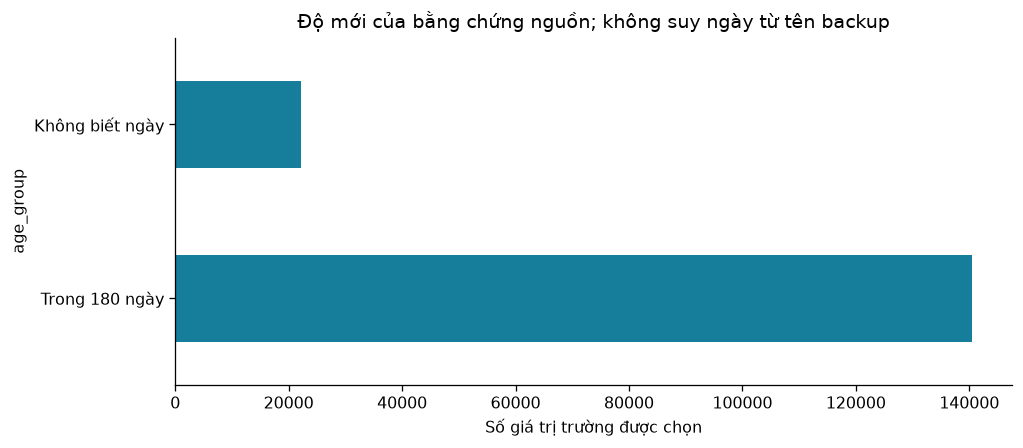

,location,normalized_name,count,ids
3819,Hà Nội,highlands coffee,66,osm:node:10002371857 | osm:node:10082412846 | ...
196,An Giang,cong vien,36,osm:way:1108260166 | osm:way:1108260510 | osm:...
5215,Hà Nội,the coffee house,33,osm:node:11039425483 | osm:node:4697346784 | o...
4065,Hà Nội,lotteria,25,osm:node:10621408642 | osm:node:11799743443 | ...
3912,Hà Nội,kfc,24,osm:node:11212195515 | osm:node:11237992813 | ...
5113,Hà Nội,starbucks,20,osm:node:10002371862 | osm:node:10269656431 | ...
3063,Hà Nội,cong ca phe,20,osm:node:12372377830 | osm:node:14064444702 | ...
12148,Đà Nẵng,highlands coffee,19,osm:node:11609564692 | osm:node:13036529160 | ...
4869,Hà Nội,pizza hut,18,osm:node:13912681353 | osm:node:2399180443 | o...
4161,Hà Nội,mixue,14,osm:node:11212149484 | osm:node:11212195517 | ...


,Rating hợp lệ,Giờ có cấu trúc,Ảnh đã chọn,Thời lượng riêng,count
0,True,True,True,True,13816
1,True,False,True,True,1150
2,True,True,False,True,942
3,False,False,False,True,48
4,False,False,False,False,22
5,True,False,False,True,20
6,False,True,False,True,9
7,False,True,False,False,5
8,False,False,True,False,2
9,True,False,False,False,2


In [6]:
from where2go.ranking import normalize
times = pd.to_datetime(provenance.observed_at, errors="coerce", utc=True)
reference = pd.Timestamp(REFERENCE_DATE, tz="UTC") + pd.Timedelta(days=1)
age = (reference-times).dt.total_seconds()/86400
freshness = pd.Series(np.select([times.isna(), age.lt(0), age.le(180)],
                                ["Không biết ngày", "Sau ngày phân tích", "Trong 180 ngày"], default="Hơn 180 ngày"))
freshness_table = freshness.value_counts().rename_axis("age_group").reset_index(name="field_count")
table(freshness_table, "provenance_freshness")
freshness_table.set_index("age_group").field_count.plot.barh(figsize=(9, 4), color=COLOR)
plt.xlabel("Số giá trị trường được chọn")
plt.title("Độ mới của bằng chứng nguồn; không suy ngày từ tên backup")
savefig("07_tinh_moi")
duplicates = pois.assign(normalized_name=pois.name.map(normalize)).groupby(["location", "normalized_name"]).agg(
    count=("poi_id", "size"), ids=("poi_id", lambda x: " | ".join(x))).reset_index()
duplicates = duplicates[duplicates["count"]>1].sort_values("count", ascending=False)
duplicates.to_csv(OUT/"duplicate_name_candidates.csv", index=False, encoding="utf-8-sig")
display(duplicates.head(15))
missing_signatures = (~flags[["Rating hợp lệ", "Giờ có cấu trúc", "Ảnh đã chọn", "Thời lượng riêng"]]).value_counts()
display(missing_signatures.head(10).rename("count").reset_index())

## 6. Thu thập bổ sung: phân biệt lấy được trường và ghép đúng thực thể

Đọc báo cáo pilot và mở rộng đã lưu. Mẫu được chọn có chủ đích và hai nhóm khác độ khó;
không so tỷ lệ 95% và 54,26% như một thí nghiệm ngẫu nhiên, không gọi 89/149 là accuracy.

,batch,targets,accepted,needs_review,human_verified
0,Pilot,20,19,1,0
1,Mở rộng,129,70,59,0


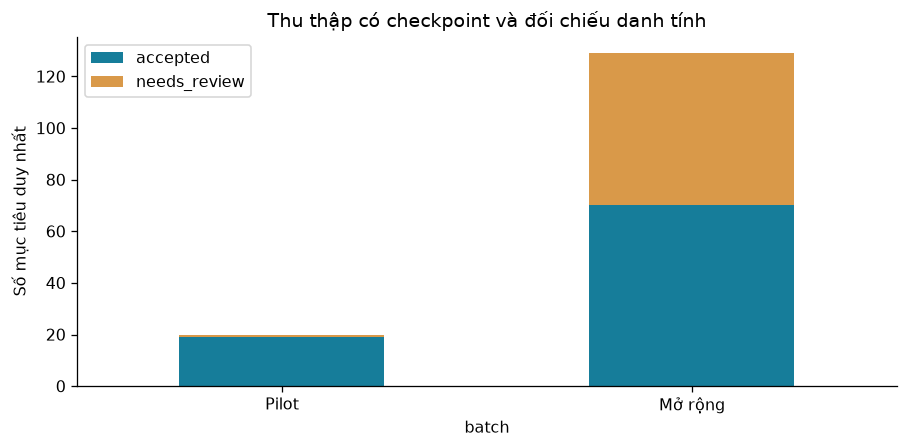

In [7]:
collection = []
for name, label in [("collection_pilot.json", "Pilot"), ("collection_expansion.json", "Mở rộng")]:
    report = json.loads((ROOT/"data/reports/v2"/name).read_text(encoding="utf-8"))
    collection.append({"batch": label, "targets": report["unique_results"], "accepted": report["accepted"],
                       "needs_review": report["needs_review"], "human_verified": report["human_verified"]})
collection = pd.DataFrame(collection)
table(collection, "collection_outcomes")
collection.set_index("batch")[["accepted", "needs_review"]].plot.bar(stacked=True, figsize=(8, 4), color=[COLOR, "#d99949"])
plt.xticks(rotation=0)
plt.ylabel("Số mục tiêu duy nhất")
plt.title("Thu thập có checkpoint và đối chiếu danh tính")
savefig("08_thu_thap")

## 7. Kiểm chứng công thức AHP và ảnh hưởng bất định

Gọi trực tiếp hàm production. Sáu hệ số $\gamma$ bằng nhau làm trọng số sau giải mờ trùng crisp;
đây là tính chất đại số, không phải bằng chứng fuzzy tăng độ chính xác. Biến thiên từng hệ số bên dưới
là kiểm tra độ nhạy thiết kế, **không** là phán đoán chuyên gia đã khảo sát.

,gamma_pair_preference_quality,preference_match,place_quality,drive_time,data_confidence
0,1.0,0.400000,0.300000,0.200000,0.100000
1,1.2,0.400199,0.300149,0.199768,0.099884
2,1.4,0.400677,0.300508,0.199210,0.099605
3,1.6,0.401317,0.300987,0.198464,0.099232
4,1.8,0.402051,0.301538,0.197607,0.098803
5,2.0,0.402841,0.302131,0.196685,0.098343


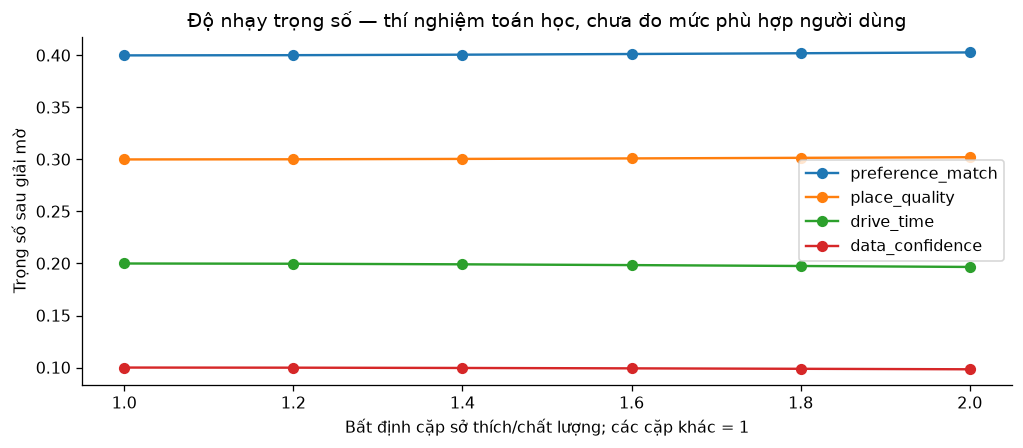

,criterion,crisp,fuzzy_default
0,preference_match,0.4,0.4
1,place_quality,0.3,0.3
2,drive_time,0.2,0.2
3,data_confidence,0.1,0.1


CR = **0**; sai khác trọng số lớn nhất **5.55e-17**.

,preference_match,place_quality,drive_time,data_confidence,topsis
Ví dụ A,0.9,0.88,900.0,0.50,0.628778
Ví dụ B,0.7,0.92,600.0,0.75,0.645768
Ví dụ C,0.4,0.50,300.0,0.25,0.351971


In [8]:
from where2go.v2.models import DEFAULT_COMPARISONS, CRITERIA
from where2go.v2.ranking import ahp_weights
from where2go.ranking import topsis

crisp, cr = ahp_weights(DEFAULT_COMPARISONS, [1]*6)
fuzzy, _ = ahp_weights(DEFAULT_COMPARISONS, [1.2]*6)
assert np.allclose(crisp, fuzzy, atol=1e-12)
weight_rows = []
for gamma in np.linspace(1, 2, 6):
    weights, _ = ahp_weights(DEFAULT_COMPARISONS, [float(gamma), 1, 1, 1, 1, 1])
    weight_rows.append({"gamma_pair_preference_quality": gamma, **dict(zip(CRITERIA, weights))})
sensitivity = pd.DataFrame(weight_rows)
table(sensitivity, "weight_sensitivity")
sensitivity.set_index("gamma_pair_preference_quality").plot(marker="o", figsize=(9, 4))
plt.ylabel("Trọng số sau giải mờ")
plt.xlabel("Bất định cặp sở thích/chất lượng; các cặp khác = 1")
plt.title("Độ nhạy trọng số — thí nghiệm toán học, chưa đo mức phù hợp người dùng")
savefig("09_do_nhay_ahp")
display(pd.DataFrame({"criterion": CRITERIA, "crisp": crisp, "fuzzy_default": fuzzy}))
display(Markdown(f"CR = **{cr:.3g}**; sai khác trọng số lớn nhất **{np.abs(crisp-fuzzy).max():.3g}**."))

# Ví dụ số GIẢ ĐỊNH chỉ để minh họa TOPSIS: sở thích, chất lượng, giây lái xe, confidence.
example = np.array([[.9, .88, 900, .5], [.7, .92, 600, .75], [.4, .5, 300, .25]])
example_scores = topsis(example, fuzzy, (True, True, False, True))
display(pd.DataFrame(example, columns=CRITERIA, index=["Ví dụ A", "Ví dụ B", "Ví dụ C"]).assign(topsis=example_scores))

## 8. Kết quả nghiên cứu tình huống trong kho mã

Evaluator gồm 16 kịch bản thiết kế × 4 phương pháp; 4 development, 12 holdout là **phân chia kịch bản**,
không phải chia lịch sử tương tác để huấn luyện/test. Notebook không gọi mạng hoặc chạy lại evaluator.
Chỉ so sánh số điểm/thời gian/trạng thái; chưa có nhãn độc lập để tính Precision, Recall, NDCG.
So sánh thời gian chạy bị ảnh hưởng cache và thứ tự chạy cố định.

,method,runs,provisional,mean_attractions,mean_drive_minutes,median_runtime_seconds
0,crisp,16,16,3.8750,33.973750,0.36505
1,equal,16,16,3.9375,28.671875,0.37045
2,fuzzy,16,16,3.8750,33.973750,0.32935
3,nearby,16,16,3.9375,21.602500,0.83490


,split,method,runs,mean_attractions,mean_drive_minutes
0,development,crisp,4,3.250000,28.827500
1,development,equal,4,3.500000,17.232500
2,development,fuzzy,4,3.250000,28.827500
3,development,nearby,4,3.500000,11.822500
4,holdout,crisp,12,4.083333,35.689167
5,holdout,equal,12,4.083333,32.485000
6,holdout,fuzzy,12,4.083333,35.689167
7,holdout,nearby,12,4.083333,24.862500


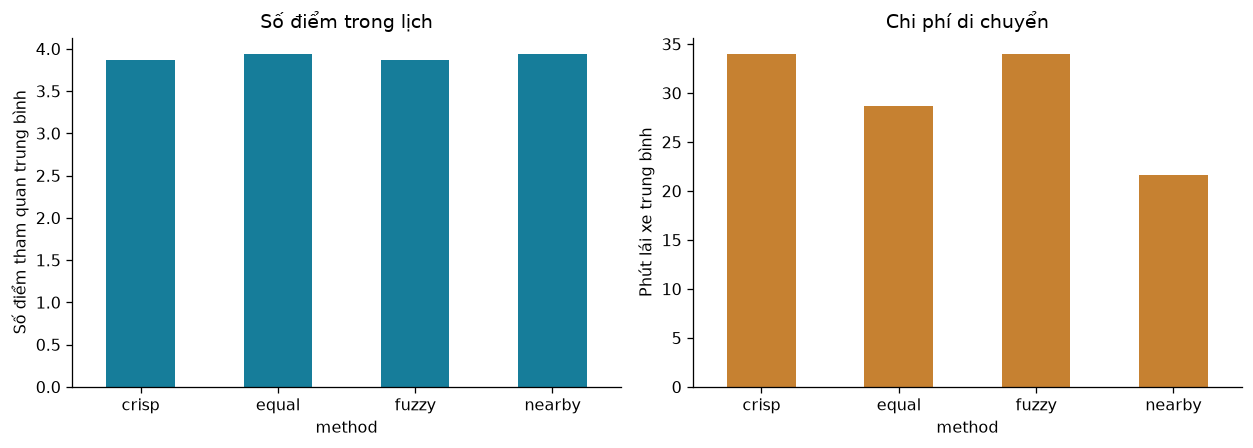

Crisp và fuzzy cho cùng danh sách/thứ tự ở **16/16** kịch bản. Đi ít phút hơn hoặc ghé nhiều điểm hơn chưa chứng minh người dùng hài lòng hơn.

{'scenario_count': 7,
 'legacy_schedule_count': 2,
 'new_schedule_count': 7,
 'new_actionable_count': 7,
 'new_full_must_original_window': 5,
 'new_full_must_any_window': 7,
 'legacy_median_ms': 20.5,
 'new_median_ms': 488.3,
 'new_max_ms': 1377.3,
 'timeline_route_consistency': 'PASS'}

Bảy tình huống planner được chọn có chủ đích. Có lịch sau đổi khung giờ khác với giữ đủ điểm trong khung ban đầu.

In [9]:
evaluation_path = ROOT/"data/reports/v2/evaluation.json"
evaluation = json.loads(evaluation_path.read_text(encoding="utf-8"))
assert evaluation["dataset_version"] == summary["dataset_version"], "Evaluator khác snapshot; cần chạy lại"
evaluated = pd.DataFrame(evaluation["results"])
assert len(evaluated) == 64 and not evaluated.duplicated(["scenario_id", "method"]).any()
evaluation_stats = evaluated.groupby("method").agg(runs=("status", "size"),
    provisional=("status", lambda x: int(x.eq("provisional").sum())),
    mean_attractions=("attraction_count", "mean"), mean_drive_minutes=("drive_minutes", "mean"),
    median_runtime_seconds=("runtime_seconds", "median")).reset_index()
table(evaluation_stats, "evaluation_summary")
table(evaluated.groupby(["split", "method"]).agg(runs=("status", "size"),
     mean_attractions=("attraction_count", "mean"), mean_drive_minutes=("drive_minutes", "mean")).reset_index(), "evaluation_by_split")
crisp_runs = evaluated[evaluated.method.eq("crisp")].set_index("scenario_id")
fuzzy_runs = evaluated[evaluated.method.eq("fuzzy")].set_index("scenario_id")
same_orders = sum(crisp_runs.at[i,"selected_poi_ids"] == fuzzy_runs.at[i,"selected_poi_ids"] for i in crisp_runs.index)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
evaluation_stats.set_index("method").mean_attractions.plot.bar(ax=axes[0], color=COLOR)
evaluation_stats.set_index("method").mean_drive_minutes.plot.bar(ax=axes[1], color="#c68131")
axes[0].set(ylabel="Số điểm tham quan trung bình", title="Số điểm trong lịch")
axes[1].set(ylabel="Phút lái xe trung bình", title="Chi phí di chuyển")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
savefig("10_doi_chieu_phuong_phap")
display(Markdown(f"Crisp và fuzzy cho cùng danh sách/thứ tự ở **{same_orders}/16** kịch bản. "
                 "Đi ít phút hơn hoặc ghé nhiều điểm hơn chưa chứng minh người dùng hài lòng hơn."))
trip = json.loads((ROOT/"data/reports/v2/trip_choices_evaluation.json").read_text(encoding="utf-8"))
assert trip["dataset_version"] == summary["dataset_version"]
display(trip["summary"])
display(Markdown("Bảy tình huống planner được chọn có chủ đích. Có lịch sau đổi khung giờ khác với giữ đủ điểm trong khung ban đầu."))

## 9. Đánh giá dữ liệu và ưu tiên cải thiện

**Điểm tốt:** truy nguyên từng trường, ID ổn định, bảo toàn quan sát mâu thuẫn, dữ liệu giờ có trạng thái unknown,
và tách khám phá khỏi điều kiện gợi ý. **Điểm yếu:** độ phủ rating rất thấp; duration mặc định không phải nhãn thực tế;
điểm bản đồ không bảo đảm là cổng ô tô; thiếu ngày quan sát làm khó đánh giá độ mới.

Chưa thể kết luận độ chính xác vị trí, tỷ lệ ghép đúng hay mức phù hợp người dùng chỉ từ audit cấu trúc.
Ưu tiên kiểm duyệt tập 140 POI trọng tâm, lấy giờ và lối vào từ nguồn xác minh, khảo sát duration,
sau đó thu đánh giá độc lập. Nếu học theo hai paper, cần tương tác `user_id, poi_id, timestamp`
và dữ liệu ngữ cảnh phù hợp; không dùng thứ tự crawl hoặc thứ tự dòng Excel làm check-in.

In [10]:
snapshot = {
    "dataset_version": summary["dataset_version"], "reference_date": str(REFERENCE_DATE),
    "poi_count": N, "location_count": int(pois.location.nunique()),
    "status_counts": {str(k):int(v) for k,v in pois.status.value_counts().items()},
    "category_counts": {str(k):int(v) for k,v in categories.items()},
    "top_two_location_share": top_share,
    "coverage": {row["field"]: {"count":int(row["present"]), "denominator":N, "percent":float(row["percent"])}
                 for row in coverage.to_dict("records")},
    "ratings": rating_stats, "duplicate_name_groups": len(duplicates),
    "same_crisp_fuzzy_orders": same_orders, "crisp_weights": crisp.tolist(), "fuzzy_weights": fuzzy.tolist(),
    "collection_accepted": int(collection.accepted.sum()), "collection_targets": int(collection.targets.sum()),
    "unknown_provenance_date": int(times.isna().sum()), "selected_fields": len(provenance),
    "source_sha256": {p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(DATA.glob("*.csv"))},
    "evaluation_sha256": hashlib.sha256(evaluation_path.read_bytes()).hexdigest(),
    "versions": {p:metadata.version(p) for p in ["numpy", "pandas", "matplotlib", "scikit-learn", "nbformat"]},
    "limits": ["No independent user labels", "No field verification inferred", "No paper models trained", "No network requested"],
}
(OUT/"analysis_summary.json").write_text(json.dumps(snapshot, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
display(Markdown(f"**PASS:** xuất 10 biểu đồ; bảng CSV và `analysis_summary.json` tại `{OUT.relative_to(ROOT)}`. "
                 "Các con số cần đối chiếu lại khi đổi snapshot."))

**PASS:** xuất 10 biểu đồ; bảng CSV và `analysis_summary.json` tại `data\reports\analysis`. Các con số cần đối chiếu lại khi đổi snapshot.

## 11. Thực nghiệm hệ gợi ý POI

Luồng đang phục vụ ở trang chủ là nội dung + ngữ cảnh + AHP–TOPSIS. Các bảng lịch trình ở phần trước là bằng chứng lịch sử của planner, không phải phép đo relevance POI.

Chạy `python scripts/evaluate_recommendations.py` trước để tạo 16 bối cảnh × 6 phương pháp. Bốn development và 12 holdout chia **theo yêu cầu**; TF-IDF fit trên metadata catalog, không học lịch sử người dùng. Mỗi bối cảnh dùng chung một tập ứng viên/ma trận cho sáu phương pháp. Thí nghiệm pool 20/40/80 dùng cùng chế độ khoảng cách địa lý để tránh lẫn tác động OSRM. Mẫu trọng số chưa được tối ưu theo nhãn.


,scenario_id,split,method,travel_metric,candidates,returned,unique_categories,category_entropy,mean_distance_km
0,HN-DEV-01,development,nearby,road_time,96,10,3,1.360964,0.397337
1,HN-DEV-01,development,quality,road_time,96,10,5,1.770951,4.796820
2,HN-DEV-01,development,content,road_time,96,10,2,0.468996,3.870492
3,HN-DEV-01,development,equal,road_time,96,10,3,1.360964,1.061222
4,HN-DEV-01,development,crisp,road_time,96,10,3,1.360964,1.253022
...,...,...,...,...,...,...,...,...,...
91,DN-HOLD-06,holdout,quality,road_time,95,10,7,2.646439,5.732118
92,DN-HOLD-06,holdout,content,road_time,95,10,3,1.156780,4.303839
93,DN-HOLD-06,holdout,equal,road_time,95,10,5,1.960964,2.657695
94,DN-HOLD-06,holdout,crisp,road_time,95,10,5,2.246439,2.835063


travel_metric
road_time              12
geographic_distance     4
Name: bối cảnh, dtype: int64

,split,method,unique_categories,category_entropy,mean_distance_km
0,development,content,3.250000,1.137972,5.760922
1,development,crisp,3.750000,1.451205,3.640747
2,development,equal,4.000000,1.631687,3.405219
3,development,fuzzy,3.750000,1.451205,3.640747
4,development,nearby,3.250000,1.425716,0.511854
5,development,quality,5.500000,2.096439,7.211674
6,holdout,content,3.083333,1.208428,8.609987
7,holdout,crisp,3.666667,1.509935,6.686984
8,holdout,equal,4.000000,1.611792,6.112654
9,holdout,fuzzy,3.666667,1.509935,6.686984


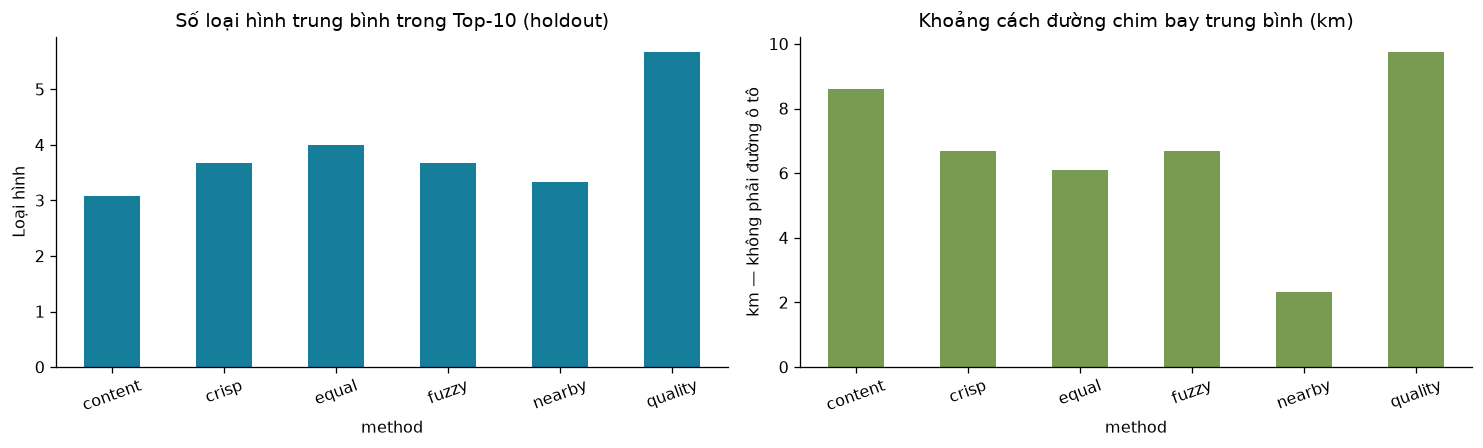

Đa dạng và khoảng cách là đặc tính kết quả, không chứng minh mức phù hợp. Danh sách chuyên đề có thể ít loại hình mà vẫn đúng nhu cầu.

In [11]:
RECO = ROOT / "data/reports/recommendations"
recommendation_eval = json.loads((RECO/"evaluation.json").read_text(encoding="utf-8"))
assert recommendation_eval["dataset_version"] == summary["dataset_version"]
assert recommendation_eval["policy_version"] == "poi-recommendation-1.0"
reco_runs = recommendation_eval["results"]
assert len(reco_runs) == 96
records = []
for run in reco_runs:
    cats = pd.Series([p["category"] for p in run["items"]], dtype="object").value_counts()
    probs = cats/cats.sum() if len(cats) else cats
    records.append({"scenario_id":run["scenario_id"],"split":run["split"],"method":run["method"],
                    "travel_metric":run["travel_metric"],"candidates":run["candidate_count"],
                    "returned":len(run["items"]),"unique_categories":len(cats),
                    "category_entropy":float(-(probs*np.log2(probs)).sum()),
                    "mean_distance_km":float(np.mean([p["explanation"]["distance_km"] for p in run["items"]]))})
reco_frame = pd.DataFrame(records)
table(reco_frame,"recommendation_runs")
mode_counts = reco_frame.drop_duplicates("scenario_id").travel_metric.value_counts()
display(mode_counts.rename("bối cảnh"))
reco_means = reco_frame.groupby(["split","method"])[["unique_categories","category_entropy","mean_distance_km"]].mean().reset_index()
table(reco_means,"recommendation_by_split")
fig,axes = plt.subplots(1,2,figsize=(13,4))
hold = reco_frame[reco_frame.split=="holdout"].groupby("method")
hold.unique_categories.mean().plot.bar(ax=axes[0],color=COLOR,rot=20,title="Số loại hình trung bình trong Top-10 (holdout)")
hold.mean_distance_km.mean().plot.bar(ax=axes[1],color="#799b51",rot=20,title="Khoảng cách đường chim bay trung bình (km)")
axes[0].set_ylabel("Loại hình");axes[1].set_ylabel("km — không phải đường ô tô")
savefig("11_goi_y_top_k")
display(Markdown("Đa dạng và khoảng cách là đặc tính kết quả, không chứng minh mức phù hợp. Danh sách chuyên đề có thể ít loại hình mà vẫn đúng nhu cầu."))


## 12. Tiêu chí, độ phủ và độ nhạy

Độ phủ catalog của một phương pháp = số POI khác nhau xuất hiện trong các Top-10 / số POI đủ điều kiện đề xuất ở hai địa bàn trong snapshot. Entropy loại hình $H=-\sum_c p_c\log_2p_c$ đo sự phân tán trong danh sách. Overlap@10 = kích thước giao / độ dài danh sách tham chiếu; thứ tự vẫn có thể đổi khi overlap bằng 1. Không so sánh trực tiếp điểm TOPSIS giữa hai pool hay hai phương pháp.


,preference_match,place_quality,travel_cost,data_confidence,scenario_id,metric,poi_id
0,0.000000,0.500000,1009.7,0.5,HN-DEV-01,road_time,osm:node:10011953034
1,0.000000,0.500000,793.0,0.5,HN-DEV-01,road_time,osm:node:10082412846
2,0.016909,0.868680,362.4,0.5,HN-DEV-01,road_time,osm:node:10098130619
3,0.026331,0.500000,546.0,0.5,HN-DEV-01,road_time,osm:node:10098130620
4,0.026331,0.500000,428.8,0.5,HN-DEV-01,road_time,osm:node:10098130621
...,...,...,...,...,...,...,...
1585,1.000000,0.859968,217.2,0.5,DN-HOLD-06,road_time,osm:way:204790989
1586,1.000000,0.780072,295.3,0.5,DN-HOLD-06,road_time,osm:way:204885903
1587,1.000000,0.840206,208.5,0.5,DN-HOLD-06,road_time,osm:way:302872188
1588,1.000000,0.949451,532.9,0.5,DN-HOLD-06,road_time,osm:way:302944359


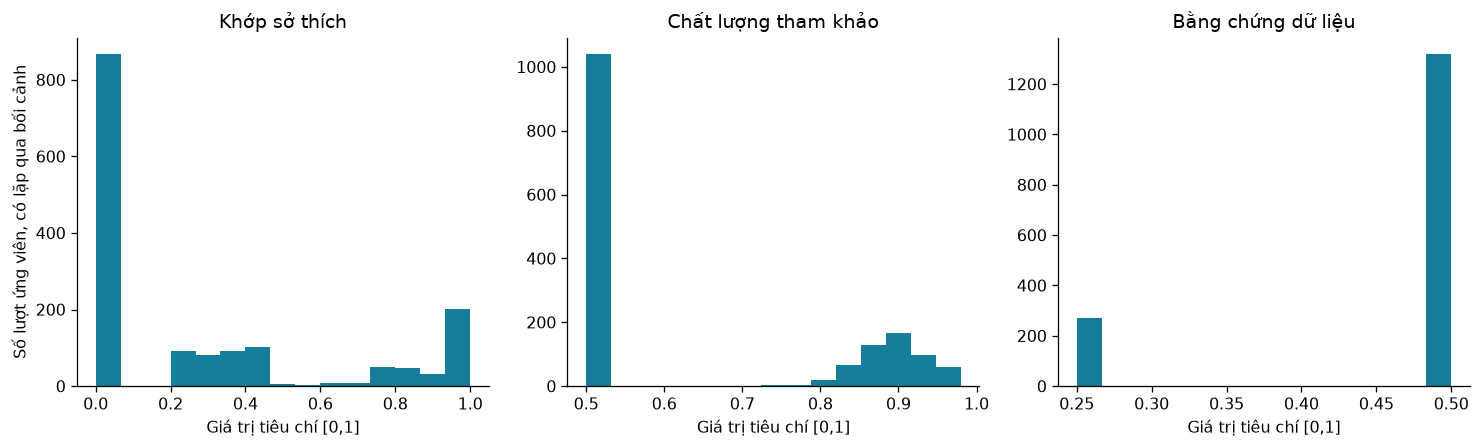

,scenario_id,split,travel_metric,eligible_count,candidate_count,kind,value,overlap_at_10
0,HN-DEV-01,development,road_time,720,96,preset,balanced,1.0
1,HN-DEV-01,development,road_time,720,96,preset,interests,0.8
2,HN-DEV-01,development,road_time,720,96,preset,nearby,0.9
3,HN-DEV-01,development,road_time,720,96,preset,quality,0.7
4,HN-DEV-01,development,road_time,720,96,travel_mode,geographic_distance,0.9
...,...,...,...,...,...,...,...,...
123,DN-HOLD-06,holdout,road_time,287,95,preset,quality,1.0
124,DN-HOLD-06,holdout,road_time,287,95,travel_mode,geographic_distance,0.9
125,DN-HOLD-06,holdout,geographic_distance,287,56,pool_size,20,0.7
126,DN-HOLD-06,holdout,geographic_distance,287,95,pool_size,40,1.0


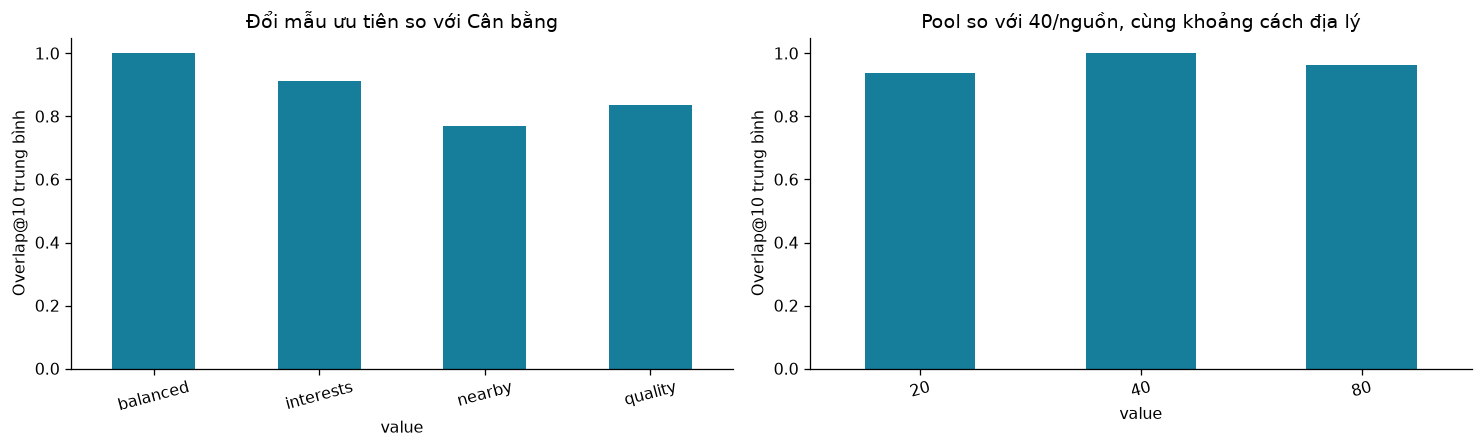

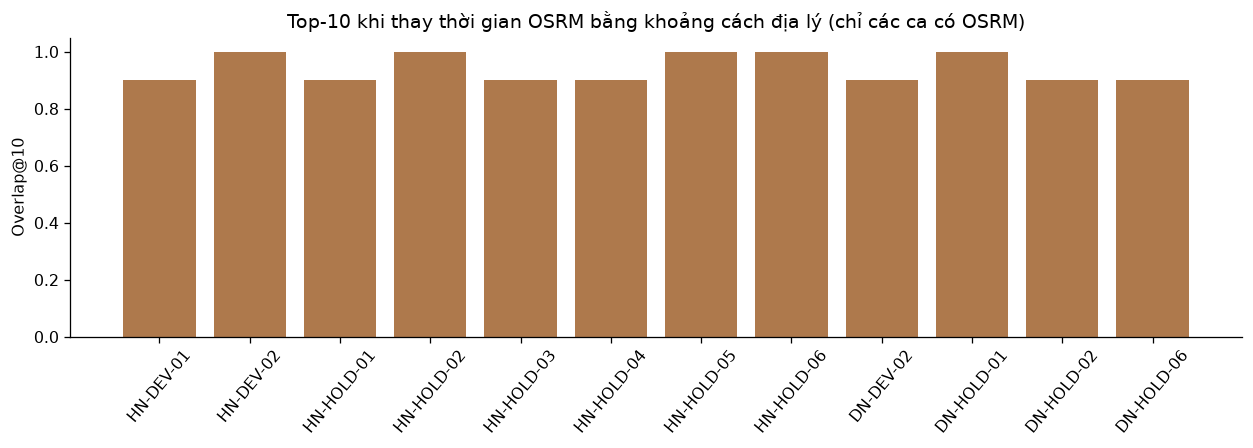

In [12]:
matrices = json.loads((RECO/"matrices.json").read_text(encoding="utf-8"))
criterion_rows = [dict(zip(["preference_match","place_quality","travel_cost","data_confidence"],r["values"]),
                       scenario_id=m["scenario_id"],metric=m["travel_metric"],poi_id=r["poi_id"]) for m in matrices for r in m["rows"]]
criterion_frame = pd.DataFrame(criterion_rows)
table(criterion_frame,"recommendation_criteria")
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,key,title in zip(axes,["preference_match","place_quality","data_confidence"],["Khớp sở thích","Chất lượng tham khảo","Bằng chứng dữ liệu"]):
    ax.hist(criterion_frame[key],bins=15,color=COLOR);ax.set_title(title);ax.set_xlabel("Giá trị tiêu chí [0,1]")
axes[0].set_ylabel("Số lượt ứng viên, có lặp qua bối cảnh")
savefig("12_phan_bo_tieu_chi")
sensitivity = pd.DataFrame(json.loads((RECO/"sensitivity.json").read_text(encoding="utf-8")))
table(sensitivity.drop(columns=["request","ids"]),"recommendation_sensitivity")
fig,axes=plt.subplots(1,2,figsize=(13,4))
for ax,kind,title in zip(axes,["preset","pool_size"],["Đổi mẫu ưu tiên so với Cân bằng","Pool so với 40/nguồn, cùng khoảng cách địa lý"]):
    sensitivity[sensitivity.kind==kind].groupby("value").overlap_at_10.mean().plot.bar(ax=ax,color=COLOR,rot=15,title=title)
    ax.set_ylim(0,1.05);ax.set_ylabel("Overlap@10 trung bình")
savefig("13_do_nhay_goi_y")
mode_comparison=sensitivity[(sensitivity.kind=="travel_mode") & (sensitivity.travel_metric=="road_time")]
fig,ax=plt.subplots(figsize=(11,4))
if len(mode_comparison):
    ax.bar(mode_comparison.scenario_id,mode_comparison.overlap_at_10,color="#ae794c")
    ax.tick_params(axis="x",rotation=50);ax.set_ylim(0,1.05)
ax.set_title("Top-10 khi thay thời gian OSRM bằng khoảng cách địa lý (chỉ các ca có OSRM)")
ax.set_ylabel("Overlap@10")
savefig("14_ngu_canh_duong_di")


## 13. Phiếu chấm, kết quả chất lượng và giới hạn

Sao chép `grading_template.csv` thành phiếu riêng; nhóm chấm 0 = không phù hợp, 1 = ít phù hợp, 2 = phù hợp, 3 = rất phù hợp với ngữ cảnh được ghi. Mẫu phiếu đã xáo trộn, không ghi thuật toán/thứ hạng. Chấm xong chạy evaluator với `--grades <đường_dẫn_phiếu>`; không chạy lại pool trong lúc đang chấm.

Precision@K dùng relevance ≥2 và mẫu số K kể cả khi trả ít hơn K. NDCG@K dùng gain $2^g-1$, IDCG chỉ trên union Top-10 đã chấm. Bất kỳ nhãn nào trong pool còn thiếu thì không tính cả hai chỉ số cho bối cảnh đó; IDCG=0 thì NDCG không xác định. Đây là tự đánh giá theo nhóm, có thiên lệch tác giả và pooling, chưa phải nghiên cứu người dùng độc lập.


In [13]:
quality_path=RECO/"quality_metrics.json"
quality_status="NOT GRADED"
if quality_path.exists():
    quality=json.loads(quality_path.read_text(encoding="utf-8"))
    assert quality["dataset_version"]==recommendation_eval["dataset_version"]
    assert quality["policy_version"]==recommendation_eval["policy_version"]
    assert quality["evaluation_sha256"]==hashlib.sha256((RECO/"evaluation.json").read_bytes()).hexdigest()
    qframe=pd.DataFrame(quality["results"])
    table(qframe,"recommendation_quality")
    judged=qframe[qframe.precision.notna()]
    if len(judged):
        quality_status="PARTIALLY GRADED" if len(judged)<len(qframe) else "GRADED"
        display(judged.groupby(["split","method","k"])[["precision","ndcg"]].mean())
    else:
        display(Markdown("**Chưa có nhãn đã chấm: không báo Precision/NDCG và không suy chất lượng từ kiểm thử.**"))
else:
    display(Markdown("**NOT GRADED:** phiếu chấm được chuẩn bị nhưng chưa có đánh giá của nhóm."))
from where2go.v2.recommendations import POLICY_VERSION
assert POLICY_VERSION==recommendation_eval["policy_version"]
method_ids={method:set(p["poi_id"] for r in reco_runs if r["method"]==method for p in r["items"]) for method in reco_frame.method.unique()}
# CSV export carries exactly the serving-quality fields; denominator is a static catalog gate, before date/radius.
focus=pois[pois.location.isin(["Hà Nội","Đà Nẵng"])]
eligible_denominator=int((truth(focus.serving_eligible) & truth(focus.explorable) & ~focus.business_status.isin(["temporarily_closed","permanently_closed"])).sum())
coverage_reco=pd.DataFrame([{"method":m,"unique_recommended_pois":len(ids),"eligible_denominator":eligible_denominator,
                             "catalog_coverage":len(ids)/eligible_denominator if eligible_denominator else None} for m,ids in method_ids.items()])
table(coverage_reco,"recommendation_catalog_coverage")
matches=sum([p["poi_id"] for r in reco_runs if r["scenario_id"]==s and r["method"]=="crisp" for p in r["items"]]==
            [p["poi_id"] for r in reco_runs if r["scenario_id"]==s and r["method"]=="fuzzy" for p in r["items"]] for s in reco_frame.scenario_id.unique())
reco_summary={"dataset_version":recommendation_eval["dataset_version"],"policy_version":POLICY_VERSION,"runs":len(reco_runs),
              "scenarios":int(reco_frame.scenario_id.nunique()),"travel_modes":{k:int(v) for k,v in mode_counts.items()},
              "same_crisp_fuzzy_top10":matches,"quality_status":quality_status,
              "preset_overlap":{str(k):float(v) for k,v in sensitivity[sensitivity.kind=="preset"].groupby("value").overlap_at_10.mean().items()},
              "pool_overlap":{str(k):float(v) for k,v in sensitivity[sensitivity.kind=="pool_size"].groupby("value").overlap_at_10.mean().items()},
              "road_geo_overlap_mean":float(mode_comparison.overlap_at_10.mean()) if len(mode_comparison) else None,
              "evaluation_sha256":hashlib.sha256((RECO/"evaluation.json").read_bytes()).hexdigest()}
(OUT/"recommendation_summary.json").write_text(json.dumps(reco_summary,ensure_ascii=False,indent=2),encoding="utf-8")
display(reco_summary)


,scenario_id,split,method,k,precision,ndcg,status
0,HN-DEV-01,development,nearby,5,None,None,NOT GRADED
1,HN-DEV-01,development,nearby,10,None,None,NOT GRADED
2,HN-DEV-01,development,quality,5,None,None,NOT GRADED
3,HN-DEV-01,development,quality,10,None,None,NOT GRADED
4,HN-DEV-01,development,content,5,None,None,NOT GRADED
...,...,...,...,...,...,...,...
187,DN-HOLD-06,holdout,equal,10,None,None,NOT GRADED
188,DN-HOLD-06,holdout,crisp,5,None,None,NOT GRADED
189,DN-HOLD-06,holdout,crisp,10,None,None,NOT GRADED
190,DN-HOLD-06,holdout,fuzzy,5,None,None,NOT GRADED


**Chưa có nhãn đã chấm: không báo Precision/NDCG và không suy chất lượng từ kiểm thử.**

,method,unique_recommended_pois,eligible_denominator,catalog_coverage
0,nearby,93,1235,0.075304
1,quality,31,1235,0.025101
2,content,105,1235,0.085020
3,equal,90,1235,0.072874
4,crisp,90,1235,0.072874
5,fuzzy,90,1235,0.072874


{'dataset_version': 'v2-ae66988a1053d0de',
 'policy_version': 'poi-recommendation-1.0',
 'runs': 96,
 'scenarios': 16,
 'travel_modes': {'road_time': 12, 'geographic_distance': 4},
 'same_crisp_fuzzy_top10': 16,
 'quality_status': 'NOT GRADED',
 'preset_overlap': {'balanced': 1.0,
  'interests': 0.9125,
  'nearby': 0.76875,
  'quality': 0.8375},
 'pool_overlap': {'20': 0.9375, '40': 1.0, '80': 0.9625},
 'road_geo_overlap_mean': 0.9416666666666668,
 'evaluation_sha256': '18ad5a22832e2dc7f540c51a4fdcb5cf3df91a9b26ad4c01ae8becb6d7482d1c'}